# Final Project

## Problem Description

### The Geometry

We seek the capacitance per unit length of  a circular conducting wire placed over the middle of a conducting strip. The wire radius is $a$ , and the center of the wire is located at a height $h$ over the strip. The strip has width $w$ and thickness $b$. The geometry is assumed to be two-dimensional and the structure is located in free space.

### The Tasks

#### Programming Task
Firstly express the net capacitance $C$ analytically in terms of the capacitance coefficients $C_{11}$, $C_{12}$, $C_{21}$ and $C_{22}$.

Write a program to evaluate the capacitance of a general 2D, two-conductor capacitor and geometry part to generate the geometry described previously. 

#### Numerical Test #1
Test the program by running the case $a = $ 1 mm, $b=$ 0.5 mm, $d = $ 2 mm, and $w =$ 20 mm. Determine the order of convergence and make an extrapolation to zero grid size within 1% accuracy. 

#### Numerical Test #2

Verify that your result for $C$ is reasonably close to the analytical result for an infinite plate, i.e., $w = \infty$. (The analytical result can be derived by means of image theory for a circular cylinder next to an infinitely large ground plate, where details can be found in [19].) For this part, give the extrapolated coefficient $C_{ij}$ as intermediate results. 

#### Numerical Test #3

Keeping all the other parameters the same, set $w =$  0.5 mm. Check the order of convergence and extrapolate to zero grid size, with at most 1% error. 

#### Numerical Test #4

Now you have some idea of what resolution is required. Based on this experience, compute and plot the capacitance as a function of width for the interval 0.2 mm < $w$ < 5 mm.

## Solution

In [1]:
function MoM2D(xs, ys, xe, ye, ϕ)

    """
    Arguments: 
        xs  := x-coordinate for starting points
        ys  := y-coordinate for starting points
        xe  := x-coordinate for ending points
        ye  := y-coordinate for ending points
        ϕ   := the potential
    Returns: 
        q   := total charge on each element
        σ   := charge density for each element
    """
   
    xobs = 0.5.*(xs + xe)    # Observation points
    yobs = 0.5.*(ys + ye)
    
    
    h = sqrt.((xe-xs).^2  + (ye - ys).^2)  # Length of elements
    A = zeros(Float64, length(xs),length(xs))
    for k in eachindex(xs)
        s = ( (xobs .- xs[k])*(xe[k] .- xs[k]) # diffrence square
            + (yobs .- ys[k])*(ye[k] .- ys[k]))./h[k]^2

        d = real(sqrt.(convert.(Complex{Float64}, (xobs .- xs[k]).^2 + (yobs .- ys[k]).^2 - s.^2 .* h[k]^2 .+ 1e-24)))
        # 1e-24 is a simple hack to avoid dealing with ξe/d blowing up to infinity for d=0
        # note that d.*atan.(ξe./d) = 0 for d = 0 (analytically)
        # same is true for x*ln (x^2 + d^2)
        # dot . means elementwise operation

        ξs = -s.*h[k]
        ξe = (1 .- s).*h[k]
        temp = 0.5*ξe.*log.(ξe.^2 + d.^2) - ξe + d.*atan.(ξe./d) - 
            (0.5*ξs.*log.(ξs.^2 + d.^2) - ξs + d.*atan.(ξs./d)) # correct line charge for 2d
            # log.(ξe.^2 + d.^2): distance between observation point and source point
        A[:, k] = -temp[:]/(2*π*8.854187)        
    end
    
    σ = (A\ϕ)      # Charge density
    q = h.*σ       # Charge per element
    return q, σ
end

MoM2D (generic function with 1 method)

## Define the descritization
Below is the detail of how we design our strategy for discretizing the given geometry. 

In [2]:
function get_circular_discretization(h::Float64, a::Float64, n_seg::Integer)
    """
    Compute the coordinates of the segmentation along the circle
    Arguments: 
        h           := height of the center of the circle
        a           := radius of the circle
        n_seg       := number of segments on the circle
    Returns: 
        xs      := an array of x-coordiantes of the starting points of elements
        xe      := an array of x-coordiantes of the ending points of elements
        ys      := an array of y-coordiantes of the ending points of elements
        ye      := an array of y-coordiantes of the ending points of elements
    """
    # angle per each segments
    angle_per_seg = 360 / n_seg
    # To impose symetry on our discretization,
    # we start from the upper part of the circle with an offset of half of the length of a segment
    # Note that according to polar coordinate system, the most upper part of a circle coresponds to the 90-degree position
    # The descretization begins couterclockwisely from this point
    start_angle = 90 + angle_per_seg / 2
    # go around the circle
    arr_angles = collect(range(start_angle, stop = start_angle + 360, length = n_seg + 1))
    # list of x-coordinates of end points of each segmentation 
    x_coords =  map(x -> a * cosd(x), arr_angles)
    # list of y-coordinates of end points of each segmentation 
    # Note we assume the center of the circle lies on the height of `h` above the origin of the imaginary coordinate system
    y_coords =  map(x -> a * sind(x) + h, arr_angles)
    # return xs, xe, ys, ye
    return x_coords[1:end-1], x_coords[2:end], y_coords[1:end-1], y_coords[2:end]
end

get_circular_discretization (generic function with 1 method)

In [3]:
function get_rectangular_discretization!(w::Float64, b::Float64, n_seg::Integer)
    """
    Compute the coordinates of the segmentation along the rectangle
    Arguments: 
        w           := width of the rectangle
        b           := thickness of the rectangle
        n_seg       := number of segments on the circle
    Returns: 
        xs      := an array of x-coordiantes of the starting points of elements
        xe      := an array of x-coordiantes of the ending points of elements
        ys      := an array of y-coordiantes of the ending points of elements
        ye      := an array of y-coordiantes of the ending points of elements
    """

    if n_seg < 4
        error("n_seg less than 4!")
    end

    # number of segments on the upper width and one of the sides
    num_seg_upper_half = convert(Int64, cld(n_seg, 2))
    # number of segments on the lower width and one of the sides
    num_seg_lower_half = convert(Int64, fld(n_seg, 2))
    
    # number of segments on the upper width. 
    # If `n_seg` is an odd number, then `num_seg_upper` = `num_seg_lower` + 1.
    # If `n_seg` is an odd number, then `num_seg_upper` = `num_seg_lower`.
    # See the description below for `num_seg_upper`
    num_seg_upper = convert(Int64, cld(w * num_seg_upper_half, b+w))
    # number of segments on one of the sides
    num_seg_side = floor(Int64, num_seg_upper_half - num_seg_upper)
    # number of segments on the lower width
    num_seg_lower = num_seg_lower_half - num_seg_side
    
    # Construct the list of x-coordinates of descritization points
    x_coords_lower = collect(range(w / 2, stop = -w / 2, length = num_seg_lower + 1))
    idx_x = convert(Int64, cld(num_seg_lower, 2)) + 1
    xs = x_coords_lower[idx_x: end]
    append!(xs, -w / 2 .* ones(num_seg_side - 1))
    append!(xs, collect(range(-w / 2, stop = w / 2, length = num_seg_upper + 1)))
    append!(xs, w / 2 .* ones(num_seg_side - 1))
    append!(xs, x_coords_lower[1: idx_x - 1])
    
    # Construct the list of y-coordinates of descritization points
    ys = (-b / 2) .* ones(fld(num_seg_lower, 2))
    append!(ys, collect(range(-b / 2, stop = b / 2, length = num_seg_side + 1)))
    append!(ys, b / 2 .* ones(num_seg_upper - 1))
    append!(ys, collect(range(b / 2, stop = -b / 2, length = num_seg_side + 1)))
    append!(ys, -b / 2 .* ones(cld(num_seg_lower, 2) - 1))

    # by shifting the index of arrays mentioned above can we construct the expression for the ending points
    xe = zeros(n_seg)
    xe[1:end-1] = xs[2:end]
    xe[end] = xs[1]

    ye = zeros(n_seg)
    ye[1:end-1] = ys[2:end]
    ye[end] = ys[1]

    return xs, xe, ys, ye
end

get_rectangular_discretization! (generic function with 1 method)

### Description about computing `num_seg_upper` in the above code snippet

Let $x$ be the number of the segments on the upper width of the rectangle, $n$ be the sum of the segments on both the upper width and one of the side of the rectangle.  
$$ 
\begin{aligned}
    \frac{w}{x} &= \frac{b}{n-x} \\
    bx &= wn - wx \\
    x &= \frac{wn}{b+w}
\end{aligned}
$$

In [4]:
function get_discretization(h::Float64, a::Float64, w::Float64, b::Float64, n_seg::Integer)
    """
    Get the coordinates of the segmentation along both the circle and the rectangle
    Arguments: 
        h           := height of the center of the circle
        a           := radius of the circle
        w           := width of the rectangle
        b           := thickness of the rectangle
        n_seg       := number of segments on the circle
    Returns: 
        xs      := an array of x-coordiantes of the starting points of elements
        xe      := an array of x-coordiantes of the ending points of elements
        ys      := an array of y-coordiantes of the ending points of elements
        ye      := an array of y-coordiantes of the ending points of elements
    """

    # 
    seg_per_plate = convert(Int64, n_seg / 2)

    # initialize lists for containing the coordinates of the discretization points
    xs = zeros(n_seg)
    xe = zeros(n_seg)
    ys = zeros(n_seg)
    ye = zeros(n_seg)

    # get the discretization points
    xs, xe, ys, ye = get_circular_discretization(h, a, seg_per_plate)
    xs_rect, xe_rect, ys_rect, ye_rect = get_rectangular_discretization!(w, b, seg_per_plate)

    # combine the discretization points
    append!(xs, xs_rect)
    append!(xe, xe_rect)
    append!(ys, ys_rect)
    append!(ye, ye_rect)

    return xs, xe, ys, ye
end

get_discretization (generic function with 1 method)

### Presenting the descritization
Above is the definision of the discretization of our geometry. Let's have a look on the graphic presentation of it. 

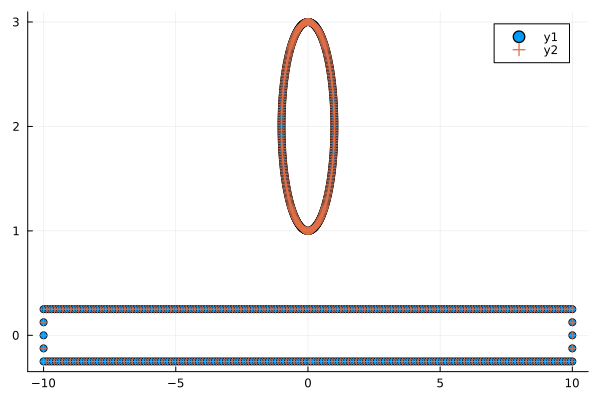

In [5]:
using Plots
h, a = 2.0, 1.0
w, b = 20.0, 0.5
n_seg = 800
xs, xe, ys, ye = get_discretization(h, a, w, b, n_seg)
scatter(xs, ys, marker=:circle)
scatter!(xe, ye, marker=:cross)

In [6]:
function get_capacitance(h, a, w, b, n_seg)

    seg_per_plate = convert(Int64, fld(n_seg , 2))
    
    xs, xe, ys, ye = get_discretization(h, a, w, b, n_seg)

    V = zeros(n_seg)
    V[1: seg_per_plate] = ones(seg_per_plate) * 0.0
    V[seg_per_plate + 1: end] = ones(seg_per_plate) * 1.0

    q, σ = MoM2D(xs, ys, xe, ye, V)
    C = sum(q[1:n_seg])
    
    return C
end

get_capacitance (generic function with 1 method)

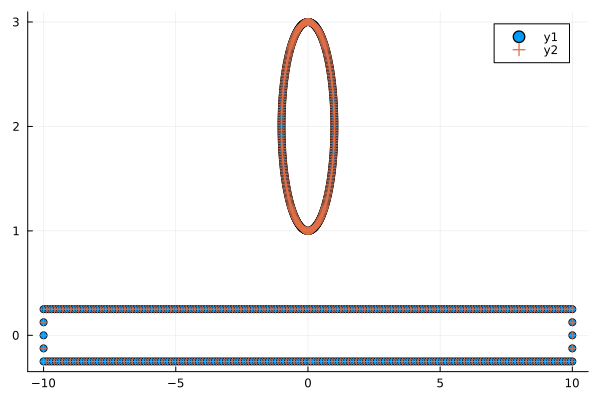

In [7]:
h, a = 2.0, 1.0
w, b = 20.0, 0.5
n_seg = 800
xs, xe, ys, ye = get_discretization(h, a, w, b, n_seg)
scatter(xs, ys, marker=:circle)
scatter!(xe, ye, marker=:cross)

In [8]:
h, a = 2.0, 1.0
# w, b = 0.5, 0.5
w, b = 20.0, 10.0
n_seg = 800
get_capacitance(h, a, w, b, n_seg)

-25.653491862549345

In [9]:
h, a = 2.0, 1.0
w, b = 0.5, 0.5
n_vals = [200; 400; 600; 800]
h2 = 0.01./n_vals
C = [get_capacitance(h, a, w, b, n_seg) for n_seg in n_vals]

4-element Vector{Float64}:
 -75.34567460622549
 -75.26462294436928
 -75.24925254956553
 -75.2437721809869

In [10]:
# Compute order of convergence: p

using Polynomials

function estimate_p(h, I)
    return log((I[end-2] - I[end-1])/(I[end-1] - I[end]))/log(h[end-2]/h[end-1])
end

p = estimate_p(h2, C)
println("Estimated order of convergence: ", p)
pfit = fit(h2.^p, C, 1)

Estimated order of convergence: 2.5434269575159876


Polynomial(-75.24339750276546 - 8.939287461576412e9*x)

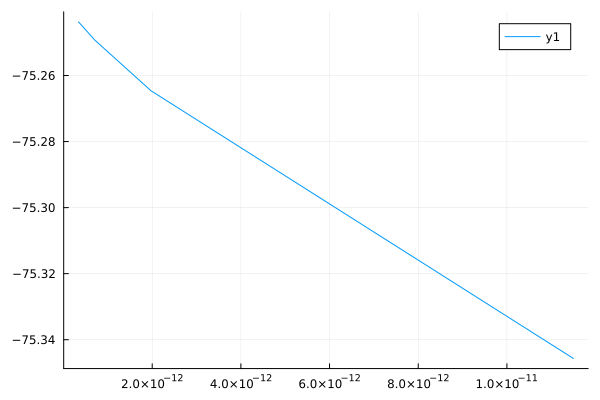

In [12]:
plot(h2.^p, C)

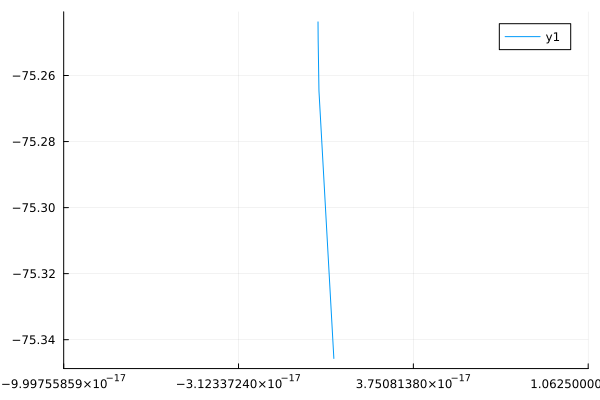

In [13]:
plot(h2.^4, C)

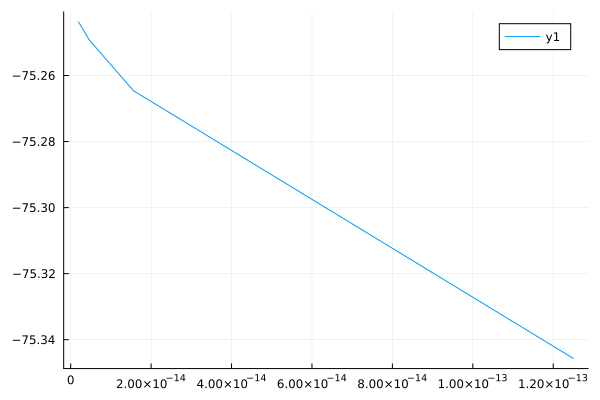

In [14]:
plot(h2.^3, C)

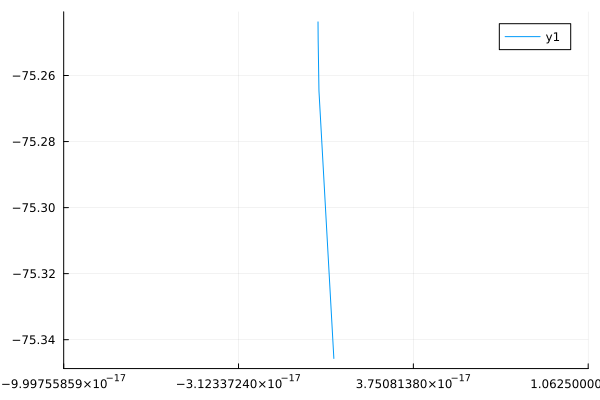

In [15]:
plot(h2.^4, C)

In [70]:
plot(h2.^8, C)

In [71]:
h, a = 2.0, 1.0
b = 0.5
n_seg = 800
lst = collect(range(0.2, 5, length=25))
C = zeros(length(lst))
for (i,w) in enumerate(lst)
  C[i] = get_capacitance(h, a, w, b, n_seg)
  # @printf("%d %f \n", i, w)
end
C

25-element Vector{Float64}:
 -76.50997945709433
 -75.64580894950915
 -74.84703196941085
 -74.04743778227109
 -73.21879989404
 -72.34855425629806
 -71.43273967748004
 -70.472696886642
 -69.4730686301083
 -68.44046842461776
 -67.38255856647481
 -66.30730294343756
 -65.22243481140482
 -64.135263802979
 -63.05233922660554
 -61.979292694876214
 -60.921127104008924
 -59.88165599865895
 -58.864155240241516
 -57.871088441048705
 -56.90427559664409
 -55.96497958497969
 -55.05399026093632
 -54.171702886283406
 -53.31799996008082

In [72]:
plot(lst, C)

# Numerical Test 2
The analyltical solution is shown below:

![Image Theory](Image-1.png)

![Image Theory](Image-2.png)

Here we define $d = D - d_i$, $C = \frac{\rho_{l}}{V_1 - V_2}$, $D = h+h = 2h$. 

For the line charge, it has its image in parallel at distance $d$. 

So we have: 

$$ \begin{aligned}
    V &= - \int^{r}_{r_0} E_r dr \\
    &= \frac{-\rho_{l}}{2\pi \varepsilon_{0}} \int^{r}_{r_0} \frac{1}{r} dr \\
    &= \frac{\rho_{l}}{2\pi \varepsilon_{0}} \ln{\frac{r_0}{r}}
\end{aligned}$$

where $r_0$ is the reference point (we denote it as zero position because it is at infinity). 

$$ \begin{aligned}
    V_M &= 
    \frac{\rho_{l}}{2\pi \varepsilon_{0}} \ln{\frac{r_0}{r}} - 
    \frac{\rho_{l}}{2\pi \varepsilon_{0}} \ln{\frac{r_0}{r_i}} \\
    &= \frac{\rho_{l}}{2 \pi \varepsilon_{0}} \ln{\frac{r_i}{r}}
\end{aligned}$$

Here $\ln{r_{0}}$ terms cancel each other, so $\frac{r_i}{r}$ is a constant. 

From the figure, we know that 
$$ \overline{OM} = a $$

and also we know that $\triangle OMP_i$ and $\triangle OPM$ are similar triangles, thus they have common angle $\angle MOP$. We come to the following result
$$ 
\begin{gathered}
    \angle OMP_i = \angle OPM \\
    \frac{\overline{P_iM}}{PM} = \frac{\overline{OP_i}}{OM} = \frac{\overline{OM}}{OP}
\end{gathered} 
$$

From the result above, we can derive

$$
\begin{gathered}
    \frac{r_i}{r} = \frac{d_i}{a} = \frac{a}{d} = constant \\
    d_i = \frac{a^2}{d}
\end{gathered} 
$$

Now we need to know how to express $d$ using $D$ and $a$.
We have already known that $d = D - d_i$, thus

$$ 
\begin{gathered}
    d = D - \frac{a^2}{d} \\
    d^2 + a^2 - Dd = 0 
\end{gathered} 
$$

Solve the above mentioned equation for $d$ bring us

$$ d = \frac{1}{2} (D \pm \sqrt{D^2 - 4a^2}) $$

We take the positive root $d = \frac{1}{2} (D + \sqrt{D^2 - 4a^2})$. In addition, we have known that 

$$ 
\begin{cases}
    V_1 = \frac{-\rho_{l}}{2\pi \varepsilon_{0}} \ln{(\frac{a}{d})} \\
    V_2 = \frac{\rho_{l}}{2\pi \varepsilon_{0}} \ln{(\frac{a}{d})} 
\end{cases} 
$$

Substituting $d$, we get
$$ \begin{aligned}
    C &= \frac{\rho_{l}}{V_1 - V_2} \\
    &= \frac{\pi \varepsilon_{0}}{\ln{(\frac{d}{a})}} \\
    &= \frac{\pi \varepsilon_{0}}{\ln{(\frac{D}{2a})} + \sqrt{(\frac{D}{2a})^2 - 1}} 
\end{aligned} $$

Now we know the expression of $C$. If we define $a = 1$ mm and $D = 2h  = 2*2 = 4$ mm, we will come to the result 
$$ C = 21.12159504 \space \text{pf/mm}$$ 